# Examples

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

## ZDT1

In [10]:
from machinable import get

with get("interface.execution.slurm", {"ranks": 8}):
    zdt1 = get(
        "interface.experiment.dmosoptimize",
        {
            "optimizer": {
                "opt_id": "zdt",
                "space": {"x%d" % (i + 1): [0.0, 1.0] for i in range(30)},
                "objective_names": ["y1", "y2"],
                "problem_parameters": {},
                "initial_maxiter": 10,
                "optimizer": "age",
                "termination_conditions": True,
                "n_initial": 3,
                "population_size": 200,
                "num_generations": 200,
                "save_surrogate_eval": True,
                "n_epochs": 2,
                "save": True,
                "file_path": "output_filepath()",
                "obj_fun_name": "ZDT1.objective",
                "obj_fun_module": "interface.experiment.examples.zdt1",
            }
        },
    ).launch()

zdt1.execution.stream_output()

Submitting 1 jobs (1 total). Proceed? [Y/n]: no


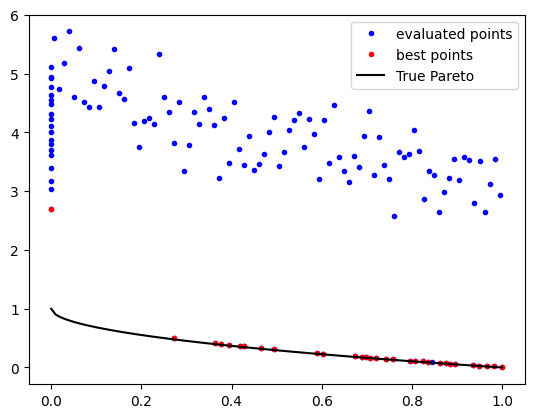

In [3]:
zdt1.pareto_plot()

In [ ]:
x = [10, 50, 100, 200, 300]
y = []
y2 = []

for population_size in x:
    zdt = zdt1.new().version({"population_size": population_size}).launch()
    hv = zdt.hypervolume([11, 11])
    igd = zdt.igd([11, 11])
    y.append(hv)
    y2.append(igd)

print(x)
print(y)
print(y2)

# Motoneurons

In [2]:
from utils.protocol import from_yaml

target_namespace: str = None
model_variant: str = "default"
num_epochs: int = 10
num_initial: int = 800
population_size: int = 400
num_generations: int = 400
seed: int = None
initial_method: str = "slh"
optimizer: str = "nsga2"
resample_fraction: float = 1.0
surrogate_method: str = "gpr"
surrogate_n_iter: int = 30000
save_surrogate_eval: bool = False
gpytorch_cuda: bool = False
sensitivity: bool = False
feasibility: bool = False


protocol: dict = from_yaml("simulation/config/motoneuron.yaml")

--No graphics will be displayed.


In [3]:
import os
import numpy as np
from miv_simulator.mechanisms import compile_and_load
from numpy.random import default_rng
from utils.neuron import load_template
from utils import ephys
from utils.protocol import ExperimentalProtocol

compile_and_load("simulation/mechanisms")

local_random = None
if seed is not None:
    local_random = default_rng(seed=seed)

celltype = protocol["Celltype"]
template_dict = protocol.get("Template", None)
template_name = None
template_file = None
template = None
if template_dict is None:
    template_name = "MN_nrn"
    template_file = "MN_nrn.hoc"
else:
    if model_variant in template_dict:
        template_name = template_dict[model_variant]["name"]
        template_file = template_dict[model_variant].get("file", None)
    else:
        raise RuntimeError(f"Unknown model variant {model_variant}")
template = load_template(template_name, f"$/{template_file}")

N_exp = len(protocol["Targets"]["f_I"]["I"])
if target_namespace is not None:
    N_exp = len(protocol["Target namespaces"][target_namespace]["f_I"]["I"])
feature_dtypes = [
    (
        "ic_constant_hold",
        np.float32,
    ),
    (
        "ic_constant_rest",
        np.float32,
    ),
    (
        "initial_v_error_hold",
        np.float32,
    ),
    (
        "rn",
        np.float32,
    ),
    (
        "tau",
        np.float32,
    ),
    ("fI", ephys.fi_value_dtype, N_exp),
    ("mean_fI_diff", np.float32),
    ("ISI", ephys.isi_value_dtype, N_exp),
    ("threshold", np.float32, N_exp),
    ("spike_amplitude", np.float32, N_exp),
]

problem_parameters = protocol["Parameters"]
variant_parameters_dict = protocol.get("Variant Parameters", {})
if model_variant in variant_parameters_dict:
    variant_parameters = variant_parameters_dict[model_variant]
    for k in variant_parameters:
        problem_parameters[k] = variant_parameters[k]

space = protocol["Space"]
variant_space_dict = protocol.get("Variant Space", {})
if model_variant in variant_space_dict:
    variant_space = variant_space_dict[model_variant]
    for k in variant_space:
        space[k] = variant_space[k]

space_sensitivity = None
if sensitivity:
    space_sensitivity = protocol.get("Space Sensitivity", None)
    variant_sensitivity_dict = protocol.get("Variant Space Sensitivity", {})

    if model_variant in variant_sensitivity_dict:
        variant_sensitivity = variant_sensitivity_dict[model_variant]
        for k in variant_sensitivity:
            space_sensitivity[k] = variant_sensitivity[k]

objective_names = [
    "rn_error",
    "tau_error",
    "fI_error",
    "spike_amplitude_error",
    "ISI_adaptation_error",
]
constraint_names = [
    "monotonic_fI",
    "rn_constr",
    "tau_constr",
    "spike_amplitude_constr",
    "first_ISI_constr",
    "ISI_adaptation_constr",
    "pre_spk_count",
    "initial_v_constr",
]

exp_protocol = ExperimentalProtocol(protocol, target_namespace=target_namespace)

N_spk_amp = min(len(exp_protocol.exp_i_lb_spk_amp), len(exp_protocol.exp_i_inj_amp_f_I))
N_spk_adpt = min(
    len(exp_protocol.exp_i_lb_spk_adaptation),
    len(exp_protocol.exp_i_inj_amp_f_I),
)
obj_targets = {
    "rn": (np.asarray(exp_protocol.target_rn, dtype=np.float32), np.float32, 2),
    "tau": (
        np.asarray(exp_protocol.target_tau, dtype=np.float32),
        np.float32,
        2,
    ),
    "ISI_adaptation": (
        np.row_stack(
            (
                exp_protocol.exp_i_inj_amp_f_I[:N_spk_adpt],
                exp_protocol.exp_i_lb_spk_adaptation[:N_spk_adpt],
                exp_protocol.exp_i_ub_spk_adaptation[:N_spk_adpt],
            )
        ),
        np.float32,
        (3, N_exp),
    ),
    "fI": (
        np.row_stack(
            (
                exp_protocol.exp_i_inj_amp_f_I,
                exp_protocol.exp_i_lb_rate_f_I,
                exp_protocol.exp_i_ub_rate_f_I,
            )
        ),
        np.float32,
        (3, N_exp),
    ),
    "spike_amplitude": (
        np.row_stack(
            (
                exp_protocol.exp_i_inj_amp_f_I[:N_spk_amp],
                exp_protocol.exp_i_lb_spk_amp[:N_spk_amp],
                exp_protocol.exp_i_ub_spk_amp[:N_spk_amp],
            )
        ),
        np.float32,
        (3, N_exp),
    ),
}
problem_metadata = np.array(
    [tuple((obj_targets[k][0] for k in sorted(obj_targets)))],
    dtype=[
        (f"{k}_target", obj_targets[k][1], obj_targets[k][2])
        for k in sorted(obj_targets)
    ],
)

# Create an optimizer
dmosopt_params = {
    "opt_id": "default",
    "obj_fun_init_name": "make_obj_fun",
    "obj_fun_init_module": "interface.experiment.examples.motoneuron",
    "obj_fun_init_args": {
        "protocol_config_dict": protocol,
        "feature_dtypes": feature_dtypes,
        "template_name": template_name,
        "target_namespace": target_namespace,
    },
    "problem_parameters": problem_parameters,
    "space": space,
    "objective_names": objective_names,
    "constraint_names": constraint_names,
    "feature_dtypes": feature_dtypes,
    "optimizer": optimizer,
    "optimizer_options": {"sampling_method": "sobol"},
    "n_initial": num_initial,
    "n_epochs": num_epochs,
    "population_size": population_size,
    "num_generations": num_generations,
    "termination_conditions": True,
    "resample_fraction": resample_fraction,
    "initial_maxiter": 10,
    "initial_method": initial_method,
    "surrogate_method": surrogate_method,
    "surrogate_options": {
        "lengthscale_bounds": (1e-5, 100.0),
        "batch_size": 100,
        "n_iter": surrogate_n_iter,
        "min_elbo_pct_change": 1.0,
        "cuda": gpytorch_cuda,
    },
    "feasibility_model": feasibility,
    "file_path": "output_filepath()",
    "save": True,
    "save_surrogate_eval": save_surrogate_eval,
    "metadata": problem_metadata,
    "local_random": local_random,
}

if space_sensitivity is not None:
    dmosopt_params["di_crossover"] = space_sensitivity
    dmosopt_params["di_mutation"] = space_sensitivity

numprocs=1
	1 
[0. 0. 0. 0. 0. 0. 0.]


In [ ]:
with get("interface.execution.slurm", {"nodes": 32, "ranks": 56}):
    motoneuron = get(
        "interface.experiment.dmosoptimize",
        {"optimizer": dmosopt_params},
    ).launch()

In [ ]:
from utils.neuron import load_template, run_iclamp
import matplotlib.pyplot as plt

data = motoneuron.load_file("best.p")

if data is None:
    raise ValueError("Data not available")

bestx, besty = data

bestx_dict = dict(bestx)

space = protocol["Space"]
variant_space_dict = protocol.get("Variant Space", {})
if model_variant in variant_space_dict:
    variant_space = variant_space_dict[model_variant]
    for k in variant_space:
        space[k] = variant_space[k]

problem_parameters = protocol["Parameters"]
variant_parameters_dict = protocol.get("Variant Parameters", {})
if model_variant in variant_parameters_dict:
    variant_parameters = variant_parameters_dict[model_variant]
    for k in variant_parameters:
        problem_parameters[k] = variant_parameters[k]

param_dict = {k: bestx_dict[k][0] for k in space}
for p in problem_parameters:
    param_dict[p] = problem_parameters[p]

template_dict = protocol.get("Template", None)
template_name = None
template_file = None
template = None
if template_dict is None:
    template_name = "MN_nrn"
    template_file = "MN_nrn.hoc"
else:
    if model_variant in template_dict:
        template_name = template_dict[model_variant]["name"]
        template_file = template_dict[model_variant].get("file", None)
    else:
        raise RuntimeError(f"Unknown model variant {model_variant}")
template = load_template(template_name, f"$/{template_file}")

cell = template(param_dict)

vec_t, vec_v = run_iclamp(cell, 0.15, 500.0, 1000.0)

plt.plot(vec_t, vec_v, linewidth=3, color="r")
plt.xlabel("Time (ms)")
plt.ylabel("V (mV)")